 **Import Libraries**



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error, r2_score

 **Upload Dataset**

In [2]:
from google.colab import files
uploaded = files.upload()

Saving car_age_price.csv to car_age_price.csv


**Load Dataset**

In [3]:
df = pd.read_csv('car_age_price.csv')

print("Dataset Loaded Successfully!")
df.head()

Dataset Loaded Successfully!


,Year,Price
0,2018,465000
1,2019,755000
2,2019,700000
3,2018,465000
4,2018,465000


**Dataset Information**

In [4]:
print("Dataset Information:\n")
df.info()

Dataset Information:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112 entries, 0 to 111
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Year    112 non-null    int64
 1   Price   112 non-null    int64
dtypes: int64(2)
memory usage: 1.9 KB


**Statistical Summary**

In [5]:
df.describe()

,Year,Price
count,112.000000,112.000000
mean,2016.669643,483866.044643
std,1.629616,91217.450533
min,2013.000000,300000.000000
25%,2015.000000,423750.000000
50%,2017.000000,500000.000000
75%,2017.000000,550000.000000
max,2020.000000,755000.000000


**Check Missing Values**

In [6]:
print(df.isnull().sum())

Year     0
Price    0
dtype: int64


**Scatter Plot**

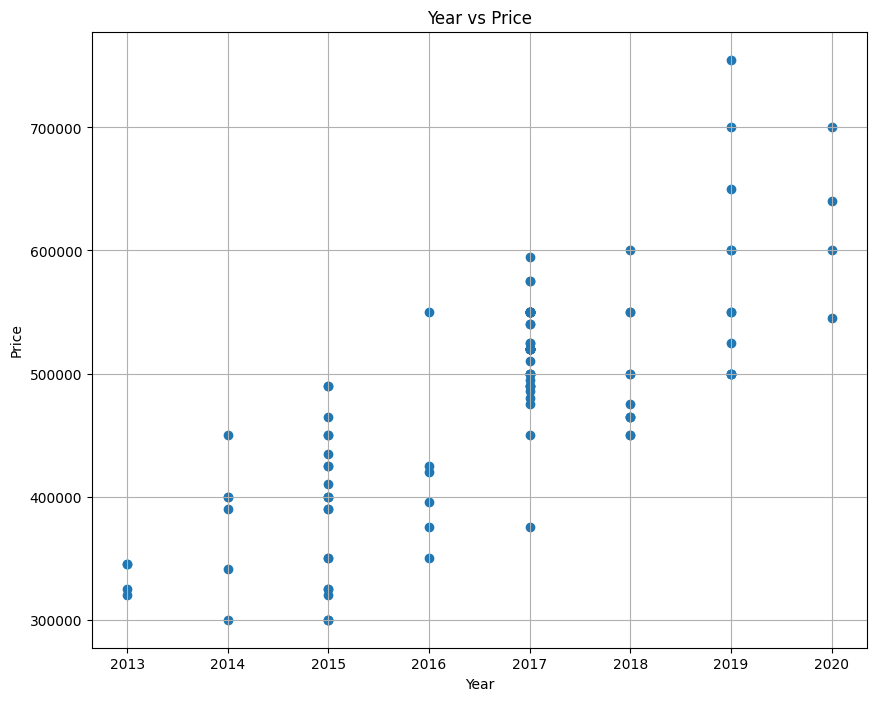

In [7]:
plt.figure(figsize=(10,8))
plt.scatter(df['Year'], df['Price'])

plt.xlabel('Year')
plt.ylabel('Price')
plt.title('Year vs Price')

plt.grid(True)
plt.show()

**Define Features and Target Variable**

In [8]:
X = df[['Year']]
y = df['Price']

**Split Dataset**

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)


Training Shape: (89, 1)
Testing Shape: (23, 1)


**Linear Regression Model**

In [10]:
linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

y_pred_linear = linear_model.predict(X_test)

linear_rmse = np.sqrt(mean_squared_error(y_test, y_pred_linear))
linear_r2 = r2_score(y_test, y_pred_linear)

print("Linear Regression RMSE:", linear_rmse)
print("Linear Regression R2 Score:", linear_r2)


Linear Regression RMSE: 65779.22359552195
Linear Regression R2 Score: 0.36759313425902185


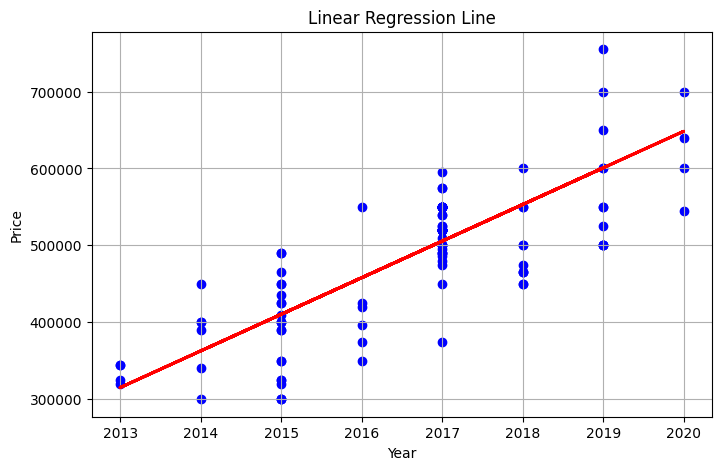

In [11]:
# Regression Line Visualization

plt.figure(figsize=(8,5))

plt.scatter(X, y, color='blue')

plt.plot(
    X,
    linear_model.predict(X),
    color='red',
    linewidth=2
)

plt.xlabel('Year')
plt.ylabel('Price')
plt.title('Linear Regression Line')

plt.grid(True)
plt.show()

*Predict Price for 2022 Model*

In [12]:
# Predict Price for 2022 Model using Linear Regression

future_year = pd.DataFrame({'Year': [2022]})

predicted_price_linear = linear_model.predict(future_year)

print("Predicted Price using Linear Regression:")
print(predicted_price_linear[0])


Predicted Price using Linear Regression:
743601.6159450412


**Lasso Regression Model**

In [13]:
lasso_model = make_pipeline(
    StandardScaler(),
    Lasso(alpha=0.1)
)

lasso_model.fit(X_train, y_train)

y_pred_lasso = lasso_model.predict(X_test)

lasso_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lasso))
lasso_r2 = r2_score(y_test, y_pred_lasso)

print("Lasso Regression RMSE:", lasso_rmse)
print("Lasso Regression R2 Score:", lasso_r2)

Lasso Regression RMSE: 65779.16855937395
Lasso Regression R2 Score: 0.36759419250268566


*Predict Price for 2022 Model*

In [14]:
# Predict Price using Lasso Regression

future_year = pd.DataFrame({'Year': [2022]})

predicted_price_lasso = lasso_model.predict(future_year)

print("Predicted Price using Lasso Regression:")
print(predicted_price_lasso[0])


Predicted Price using Lasso Regression:
743601.2667935824


**Compare Models**

In [15]:
comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Lasso Regression'],
    'RMSE': [linear_rmse, lasso_rmse],
    'R2 Score': [linear_r2, lasso_r2]
})

comparison

,Model,RMSE,R2 Score
0,Linear Regression,65779.223596,0.367593
1,Lasso Regression,65779.168559,0.367594


In [16]:
# Actual vs Predicted Values

comparison_df = pd.DataFrame({
    'Actual Price': y_test,
    'Predicted Price': y_pred_linear
})

comparison_df.head()

,Actual Price,Predicted Price
40,525000,600775.912521
65,495000,505558.776905
4,465000,553167.344713
47,450000,553167.344713
42,550000,553167.344713


**CONCLUSION**

Both Linear Regression and Lasso Regression models were created successfully.

The performance of both models was evaluated using:

    * RMSE  
    * R2 Score

The model with lower RMSE and higher R2 Score is considered the better model.

The possible price of a 2022 Hyundai Grand i10 car was also predicted successfully.